In [1]:
# load necessary libraries 
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from scipy.stats import pearsonr

In [2]:
# load data 
# To-Do: load preprocessed file and check if preprocessing is the same as implemented in this script
adata = sc.read_h5ad("../data/frangieh/adata_preprocessed.h5ad")
print(adata)
 

AnnData object with n_obs × n_vars = 191174 × 23711
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',

In [3]:
print(adata.obs.shape)

(191174, 41)


# Preprocessing 


### only keep pertubtions which have min 5 cells 
-> will also be in the preprocessing script 

In [4]:
cell_counts = adata.obs.groupby(["condition", "perturbation"]).size()

# find pertubations which have at least 5 cells in each condition
min_cells_per_cond = cell_counts.unstack(level="condition", fill_value=0)
valid_perts = min_cells_per_cond[(min_cells_per_cond >= 5).all(axis=1)].index.tolist()

# always keep 'control'
if "control" not in valid_perts:
    valid_perts.append("control")

# filter adata on these conditions
adata = adata[adata.obs["perturbation"].isin(valid_perts)].copy()

print(f"remaining Perturbationen with >= 5 cells: {len(valid_perts)}")

/tmp/ipykernel_128148/2793688431.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata.obs.groupby(["condition", "perturbation"]).size()


remaining Perturbationen with >= 5 cells: 246


### select 50 pertubations (a) most frequent and (b) randomly
a) 50 most frequent pertubations (me)
b) 50 randomly selected pertubations (me)
c) 50 pertubations with highest LFC (me)
d) cluster pertubations and select pertubations from each cluster -> most different (Thaddl)
e) greedy algorithm: select 50 pertubations which exist in different pathways (Deniz)

In [5]:
pertubation_counts = adata.obs[adata.obs['perturbation'] != 'control']['perturbation'].value_counts()
print(pertubation_counts)

# select 50 pertubations: (a) most frequent pertubations, (b) randomly

# (a)
top50_pertubations = pertubation_counts.head(50).index.tolist()

# (b)
np.random.seed(42)
all_pertubations = pertubation_counts.index.tolist()
random50_pertubations = list(np.random.choice(all_pertubations, size=50, replace=False))



perturbation
ACTA2      1215
B2M        1145
IFNGR2     1094
A2M        1092
AEBP1      1086
           ... 
UBA52        38
SNRPE        38
SNRPF        34
RACK1        32
control       0
Name: count, Length: 246, dtype: int64


In [6]:
print(all_pertubations)
print(random50_pertubations)
print(top50_pertubations)

['ACTA2', 'B2M', 'IFNGR2', 'A2M', 'AEBP1', 'CTSD', 'CD44', 'CD59', 'FGFR1', 'CD274', 'CSPG4', 'CDH19', 'JAK2', 'CD58', 'C19orf48', 'APOC2', 'ATP1B1', 'AGA', 'APOE', 'JAK1', 'CITED1', 'CTSB', 'APOD', 'AHNAK', 'FMN1', 'CDKN1A', 'FSTL3', 'FBXO32', 'CTSO', 'HLA-DRB5', 'CD47', 'MFGE8', 'C6orf226', 'HLA-A', 'CHCHD2', 'GSN', 'CMSS1', 'CCND2', 'CDKN2B', 'IDH2', 'CYP27A1', 'CD151', 'IFNGR1', 'EMP1', 'JMJD7', 'CCR10', 'NT5E', 'CKS1B', 'CTSL', 'BZW2', 'CTSA', 'GAA', 'DLL3', 'LCP1', 'SLC22A18', 'HLA-F', 'DDR1', 'CORO1A', 'LEF1-AS1', 'LAMP2', 'PSAP', 'ARMC6', 'RTP4', 'HLA-H', 'CDKN2A', 'CD63', 'GAS5', 'ENPP1', 'KDR', 'LINC00518', 'CXCR4', 'IDI2-AS1', 'KCNN4', 'NPC1', 'DAG1', 'LRPAP1', 'RB1', 'IRF3', 'GRN', 'LY96', 'CGAS', 'CDK4', 'EVA1A', 'GPNMB', 'SDC3', 'MIA', 'ITGA3', 'STAT1', 'EIF3K', 'NMRK1', 'HLA-E', 'TGFB1', 'NPC2', 'SMAD3', 'SLC5A3', 'KLF4', 'EEA1', 'MC1R', 'PFDN4', 'HSPA1A', 'DDX17', 'RBP7', 'FOS', 'NUP50-AS1', 'STOM', 'TSC22D3', 'NSG1', 'SLC26A2', 'TYR', 'TTLL1', 'RAB27A', 'SDCBP', 'S100B

## calculate pseudo bulk and LFC

In [7]:
# calculate pseudo-bulk: mean profile per pertubation group
pertubation_bulk_adata = sc.get.aggregate(adata, by=['condition', 'perturbation'], func='mean', layer = "counts")
pertubation_bulk_adata.X = pertubation_bulk_adata.layers['mean'].copy()

df_expr = pertubation_bulk_adata.to_df()
df_obs = pertubation_bulk_adata.obs

In [8]:
adata.layers["counts"]

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 628108736 stored elements and shape (191120, 23711)>

In [9]:
# calculate lfc 
eps = 1
#1e-6
df_log_expr = np.log2(df_expr + eps)

ctrl_rows = df_obs[df_obs['perturbation'] == 'control'] # per condition unperturbed cells

# mean gene expression from control cell (no pertubation)
ctrl_control = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Control'].index].mean()
ctrl_IFN_gamma = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'IFNγ'].index].mean()
ctrl_co_culture = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Co-culture'].index].mean()

# get cells with pertubations 
non_ctrl_obs = df_obs[df_obs['perturbation'] != 'control'].copy()
non_ctrl_lfc = df_log_expr.loc[non_ctrl_obs.index].copy()

# substracting baseline condition profile from expression of knockout per condition
for idx in non_ctrl_obs.index:
    condition = non_ctrl_obs.loc[idx, 'condition']
    if condition == 'Control':
        non_ctrl_lfc.loc[idx] -= ctrl_control
    elif condition == 'IFNγ':
        non_ctrl_lfc.loc[idx] -= ctrl_IFN_gamma
    elif condition == 'Co-culture':
        non_ctrl_lfc.loc[idx] -= ctrl_co_culture

log_fold_change_adata = ad.AnnData(X=non_ctrl_lfc.values, obs=non_ctrl_obs, var=pertubation_bulk_adata.var.copy())    

# FEATURE SELECTION: filter for HVGs 
log_fold_change_adata_hvg = log_fold_change_adata[:, log_fold_change_adata.var['highly_variable']].copy()

## select 50 pertubations (c) with highest LFC

In [10]:
# (c) select 50 pertubations according to their highest lfc

mask_all_ctrl = log_fold_change_adata_hvg.obs['condition'] == 'Control'
df_lfc_ctrl = log_fold_change_adata_hvg[mask_all_ctrl].to_df()
df_lfc_ctrl.index = log_fold_change_adata_hvg[mask_all_ctrl].obs['perturbation']

# 2. mean absolute LFC per Pertubation
mean_abs_lfc = df_lfc_ctrl.abs().mean(axis=1)
top_lfc50_pertubations = mean_abs_lfc.sort_values(ascending=False).head(50).index.tolist()

In [11]:
print(len(top_lfc50_pertubations))

50


In [12]:
# qualitiy control of counts and layers
counts_sample = adata.layers["counts"][:5, :5]
if hasattr(counts_sample, "toarray"):
    counts_sample = counts_sample.toarray()
print("Counts Layer Sample (should be counts):\n", counts_sample)

# 2. does pertubation_bulk_adata have linear values (mean > 0):
print("\nBulk Mean Min/Max:", df_expr.values.min(), df_expr.values.max())

# 3. look at  LFC:
print("\nLFC Min / Max / Mean:")
print(f"Min: {non_ctrl_lfc.values.min():.2f}")
print(f"Max: {non_ctrl_lfc.values.max():.2f}")
print(f"Mean: {non_ctrl_lfc.values.mean():.4f}")  # should be close to 0

Counts Layer Sample (should be counts):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Bulk Mean Min/Max: 0.0 445.7368421052632

LFC Min / Max / Mean:
Min: -3.60
Max: 5.27
Mean: 0.0036


In [13]:
print(log_fold_change_adata_hvg)

AnnData object with n_obs × n_vars = 735 × 2000
    obs: 'condition', 'perturbation', 'n_obs_aggregated'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'


## select 50 pertubations via leiden clustering (d)

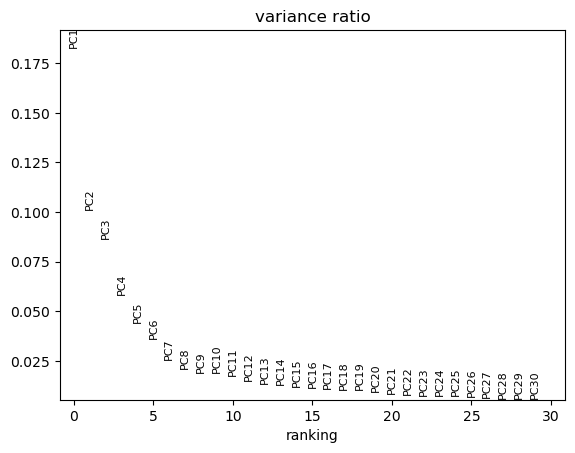

In [14]:
# PCA & Clustering of LFC-Matrix in control condition
adata_lfc_ctrl = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Control'].copy()

# PCA
sc.pp.pca(adata_lfc_ctrl, n_comps=30)

# Elbow-Plot (
sc.pl.pca_variance_ratio(adata_lfc_ctrl, n_pcs=30, log=False)

In [15]:
#  n_pcs=7
sc.pp.pca(adata_lfc_ctrl, n_comps=7)

sc.pp.neighbors(adata_lfc_ctrl)
sc.tl.leiden(adata_lfc_ctrl, resolution=0.6)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_128148/1894089431.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_lfc_ctrl, resolution=0.6)


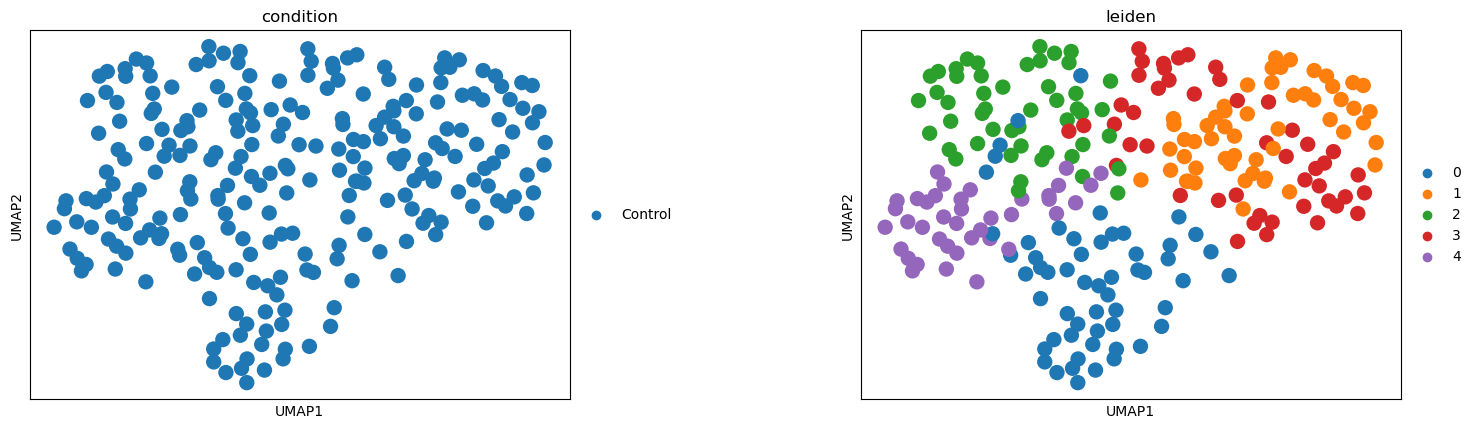

In [16]:
sc.tl.umap(adata_lfc_ctrl)
sc.pl.umap(adata_lfc_ctrl, color=['condition', 'leiden'], wspace=0.4)

In [17]:
# select 10 pertubations per cluster to get 50 pertubations 
np.random.seed(42)
cluster50_pertubations = []

for cluster_id in sorted(adata_lfc_ctrl.obs['leiden'].unique()):
    # get all pertubations per cluster
    cluster_perts = adata_lfc_ctrl.obs[adata_lfc_ctrl.obs['leiden'] == cluster_id]['perturbation'].unique().tolist()
    
    # select 10 random pertubations per cluster 
    n_samples = min(10, len(cluster_perts))
    chosen = np.random.choice(cluster_perts, size=n_samples, replace=False).tolist()
    cluster50_pertubations.extend(chosen)
    print(f"Cluster {cluster_id}: {len(chosen)} Perturbationen selected (out of {len(cluster_perts)} available ones)")

# if a cluster has less than 10 pertubations, select other pertubations to get 50 in total
if len(cluster50_pertubations) < 50:
    remaining = [p for p in adata_lfc_ctrl.obs['perturbation'].unique() if p not in cluster50_pertubations]
    needed = 50 - len(cluster50_pertubations)
    cluster50_pertubations.extend(np.random.choice(remaining, size=needed, replace=False).tolist())

print(f"\ntotal selected Knockouts: {len(cluster50_pertubations)}")

Cluster 0: 10 Perturbationen selected (out of 56 available ones)
Cluster 1: 10 Perturbationen selected (out of 54 available ones)
Cluster 2: 10 Perturbationen selected (out of 49 available ones)
Cluster 3: 10 Perturbationen selected (out of 47 available ones)
Cluster 4: 10 Perturbationen selected (out of 39 available ones)

total selected Knockouts: 50


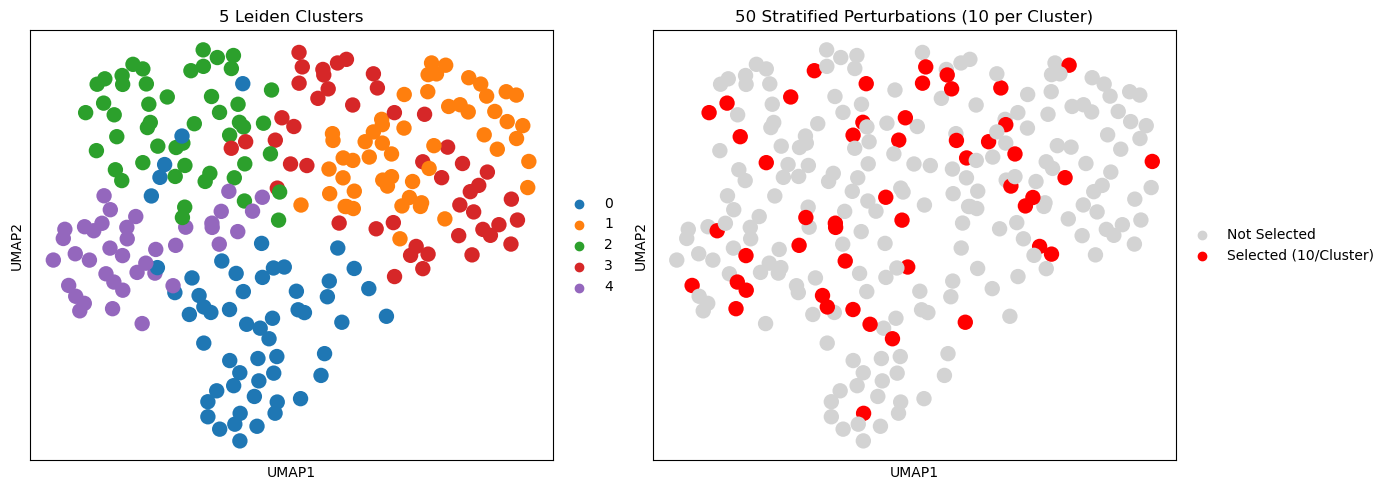

In [18]:
# visualization of 50 selected pertubations 
sc.tl.umap(adata_lfc_ctrl)

adata_lfc_ctrl.obs['selected_50'] = adata_lfc_ctrl.obs['perturbation'].apply(
    lambda x: 'Selected (10/Cluster)' if x in cluster50_pertubations else 'Not Selected'
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata_lfc_ctrl, color='leiden', ax=ax1, show=False, title='5 Leiden Clusters')
sc.pl.umap(
    adata_lfc_ctrl, 
    color='selected_50', 
    palette={'Selected (10/Cluster)': 'red', 'Not Selected': 'lightgrey'}, 
    ax=ax2, 
    show=False, 
    title='50 Stratified Perturbations (10 per Cluster)'
)

plt.tight_layout()
plt.show()

## (e) select 50 pertubations with pathway information (Deniz)
* selected pertubations should cover a lot of different pathways / should be present in different pathways 
* a lot of pertubations are present in the same pathways, it would be best to select pertubations which are present in different pathways 
* use MSigDB Hallmark Pathway Information

In [19]:
# load hallmark pathways 
hallmark = gp.get_library(name="MSigDB_Hallmark_2020", organism="Human")

hallmark_upper = {pathway: {str(g).upper() for g in genes} for pathway, genes in hallmark.items()}

In [20]:
eligible_genes = [g for g in valid_perts if g.lower() != 'control']

pathway_matrix = pd.DataFrame(0, index=eligible_genes, columns=hallmark_upper.keys(), dtype=int)
for gene in eligible_genes:
    g_up = str(gene).upper()
    for pathway, p_genes in hallmark_upper.items():
        if g_up in p_genes:
            pathway_matrix.loc[gene, pathway] = 1

In [21]:
rng = np.random.default_rng(42)
annotated_genes = pathway_matrix.index[pathway_matrix.sum(axis=1) > 0].tolist()

pathway50_pertubations = []
covered_pathways = set()
remaining = annotated_genes.copy()

while len(pathway50_pertubations) < 50 and len(remaining) > 0:
    gains = {}
    for gene in remaining:
        gene_pathways = set(pathway_matrix.columns[pathway_matrix.loc[gene] == 1])
        new_pathways = gene_pathways - covered_pathways
        gains[gene] = len(new_pathways)
        
    max_gain = max(gains.values())
    
    # if no gene is found in a new pathway, stop loop
    if max_gain == 0:
        break
        
    best_genes = [g for g, gain in gains.items() if gain == max_gain]
    chosen = rng.choice(best_genes)
    
    pathway50_pertubations.append(chosen)
    covered_pathways.update(pathway_matrix.columns[pathway_matrix.loc[chosen] == 1])
    remaining.remove(chosen)

# if < 50 Gene: fill with remaining genes
if len(pathway50_pertubations) < 50:
    extra_candidates = [g for g in eligible_genes if g not in pathway50_pertubations]
    extra = rng.choice(extra_candidates, size=50 - len(pathway50_pertubations), replace=False)
    pathway50_pertubations.extend(extra.tolist())

print(f"selected genes: {len(pathway50_pertubations)}")
print(f"covered Hallmark-pathways: {pathway_matrix.loc[pathway50_pertubations].max(axis=0).sum()} / 50")


selected genes: 50
covered Hallmark-pathways: 46 / 50


for the selection of the 50 pertubations, we now have: 
(a) most frequent pertubations: 'top50_pertubations' 
(b) randomly selected pertubations: 'random50_pertubations'
(c) 50 pertubations with highest LFC: 'top_lfc50_pertubations'
(d) 50 pertubations selected with leiden clustering: 'cluster50_pertubations'
(e) 50 pertubations selected with pathway information: 'pathway50_pertubations'

# Feature Engineering
1. baseline expression of the perturbed gene in the control condition 
2. one hot encoded vector with pathway level information for the perturbed gene + one hot encoded condition information → Deniz wollte eventuell noch baseline expression dazu machen um zu schauen, ob sich die performance ändert 
3. gene embeddings from a pre-trained foundation model 
4. CITE-seq MOFA embeddings

## Basal Expression Features
Representation of each pertubation using its baseline profile in undisturbed control cells (condition == 'Control' & perturbation == 'control')

FEATURES:
- basal_mean: Mean gene expression
- basal_detection_rate: Fraction of expressing cells (>0)
- basal_var: Expression variance

In [22]:
# filter control cells of control condition 
ctrl_sc_mask = (adata.obs['condition'] == 'Control') & (adata.obs['perturbation'] == 'control')
adata_ctrl_sc = adata[ctrl_sc_mask]
df_ctrl = adata_ctrl_sc.to_df()

In [23]:
# define function to select features of 50 pertubations 
def extract_basal_features(gene_list, df_reference):
    """
    calculates mean_expr, var_expr und detection_rate for a given gene list based on control cells in the control condition
    """
    feature_rows = []
    for gene in gene_list:
        if gene in df_reference.columns:
            vals = df_reference[gene]
            feature_rows.append({
                'mean_expr': vals.mean(),
                'var_expr': vals.var(),
                'det_rate': (vals > 0).mean()
            })
        else:
            feature_rows.append({'mean_expr': 0.0, 'var_expr': 0.0, 'det_rate': 0.0})
    return pd.DataFrame(feature_rows, index=gene_list)

In [24]:
## feature matrix X
# (a) Top 50 Most Frequent
df_X_top_50 = extract_basal_features(top50_pertubations, df_ctrl)

# (b) 50 Random
df_X_random_50 = extract_basal_features(random50_pertubations, df_ctrl)

# (c) Top 50 Highest LFC
df_X_highest_lfc = extract_basal_features(top_lfc50_pertubations, df_ctrl)

# (d) 50 Stratified (Leiden Clustering)
df_X_cluster_50 = extract_basal_features(cluster50_pertubations, df_ctrl)

# (e) 50 Pathway Coverage (MSigDB Hallmark)
df_X_pathway_50 = extract_basal_features(pathway50_pertubations, df_ctrl)

In [32]:
## targets Y
df_Y_top_50 = df_lfc_ctrl.reindex(top50_pertubations).fillna(0.0)
df_Y_random_50 = df_lfc_ctrl.reindex(random50_pertubations).fillna(0.0)
df_Y_highest_lfc = df_lfc_ctrl.reindex(top_lfc50_pertubations).fillna(0.0)
df_Y_cluster_50 = df_lfc_ctrl.reindex(cluster50_pertubations).fillna(0.0)
df_Y_pathway_50 = df_lfc_ctrl.reindex(pathway50_pertubations).fillna(0.0)

## train models 

In [34]:
# train test split 
# 40 pertubations for training and 10 for testing 
splits = {}
all_sets = {
    'Top 50 (Frequent)': (df_X_top_50, df_Y_top_50),
    'Random 50': (df_X_random_50, df_Y_random_50),
    'Top 50 (Highest LFC)': (df_X_highest_lfc, df_Y_highest_lfc),
    'Stratified 50 (Leiden)': (df_X_cluster_50, df_Y_cluster_50),
    'Pathway Coverage 50': (df_X_pathway_50, df_Y_pathway_50)
}

for name, (df_X, df_Y) in all_sets.items():
    X_tr, X_te, Y_tr, Y_te = train_test_split(
        df_X.values, df_Y.values, test_size=10, random_state=42
    )
    splits[name] = (X_tr, X_te, Y_tr, Y_te)

In [35]:
# train random forest and ridge regression 
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
}

In [36]:
results = []
predictions = {}

# training and evaluation
for split_name, (X_tr, X_te, Y_tr, Y_te) in splits.items():
    for model_name, model in models.items():
        
        # adjust model
        model.fit(X_tr, Y_tr)
        Y_pred = model.predict(X_te)
        predictions[(split_name, model_name)] = (Y_te, Y_pred)
        
        # Mean Squared Error
        mse = mean_squared_error(Y_te, Y_pred)
        
        # mean pearson corr
        corrs = []
        for i in range(len(Y_te)):
            if np.std(Y_te[i]) > 0 and np.std(Y_pred[i]) > 0:
                r, _ = pearsonr(Y_te[i], Y_pred[i])
                if not np.isnan(r):
                    corrs.append(r)
        
        mean_r = np.mean(corrs) if len(corrs) > 0 else 0.0
        
        results.append({
            'Auselection strategy': split_name,
            'Modell': model_name,
            'MSE': round(mse, 4),
            'Mean Pearson r': round(mean_r, 4)
        })

In [37]:
df_eval = pd.DataFrame(results)
print(df_eval.to_string(index=False))

     Auswahl-Strategie           Modell    MSE  Mean Pearson r
     Top 50 (Frequent) Ridge Regression 0.0023          0.8358
     Top 50 (Frequent)    Random Forest 0.0025          0.8118
             Random 50 Ridge Regression 0.0037          0.7368
             Random 50    Random Forest 0.0040          0.7226
  Top 50 (Highest LFC) Ridge Regression 0.0147          0.4186
  Top 50 (Highest LFC)    Random Forest 0.0163          0.3563
Stratified 50 (Leiden) Ridge Regression 0.0041          0.7451
Stratified 50 (Leiden)    Random Forest 0.0045          0.7117
   Pathway Coverage 50 Ridge Regression 0.0083          0.7350
   Pathway Coverage 50    Random Forest 0.0095          0.6610
